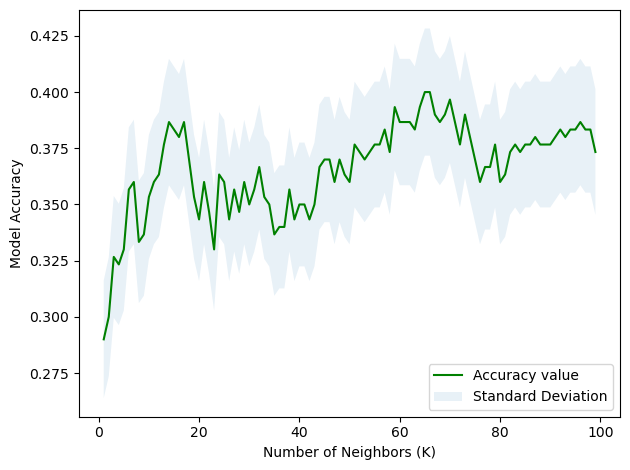

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score

Ks = 100 
accu = np.zeros((Ks - 1))
std_accu = np.zeros((Ks - 1))
for n in range(1,Ks):
    df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv')
    df['custcat'].value_counts()
    correlation_matrix = df.corr()
    
    correlation_values  = abs(df.corr()['custcat'].drop('custcat').sort_values(ascending = False))
    X = df.drop('custcat',axis =1)
    y = df['custcat']
    
    X_norm = StandardScaler().fit_transform(X)
    X_train,X_test,y_train,y_test = train_test_split(X_norm,y,test_size=0.3,random_state = 42)
    knn_model = KNeighborsClassifier(n_neighbors=n).fit(X_train,y_train)
    yhat = knn_model.predict(X_test)
    accu[n-1] = accuracy_score(y_test,yhat)
    std_accu[n-1] = np.std(yhat==y_test)/np.sqrt(yhat.shape[0])
    
plt.plot(range(1,Ks),accu,'g')
plt.fill_between(range(1,Ks),accu - 1 * std_accu,accu + 1 * std_accu, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()
